<a href="https://colab.research.google.com/github/Auta01/Natural-language-processing-NLP/blob/main/Fake_and_Real%20news%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install opendatasets

In [17]:
import requests

url = 'https://raw.githubusercontent.com/codebasics/nlp-tutorials/refs/heads/main/16_word_vectors_gensim_text_classification/fake_and_real_news.csv'
r = requests.get(url, allow_redirects=True)

# Ensure the directory exists if needed, although /content/ usually exists
with open('/content/fake_and_real_news.csv', 'wb') as f:
    f.write(r.content)

In [27]:
import pandas as pd
df = pd.read_csv('/content/fake_and_real_news.csv', engine='python', sep=',', on_bad_lines='skip')

In [41]:
df.head()

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,NaN
1,U.S. conservative leader optimistic of common ...,Real,1.0
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1.0
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,NaN
4,Democrats say Trump agrees to work on immigrat...,Real,1.0


In [42]:
df.shape

(9900, 3)

In [28]:
df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [29]:
df.shape

(9900, 2)

In [30]:
df.label.value_counts()

,count
label,
Fake,5000
Real,4900


In [43]:
df['label_num'] = df.label.map({'Fake':0, 'Real':1})
df.head()

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1


In [50]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [77]:
import spacy
import numpy as np # Import numpy for creating zero vectors

nlp = spacy.load('en_core_web_lg')

def preprocess_and_vectorize(text):
  doc = nlp(text)
  filtered_tokens = []
  for token in doc:
    if token.is_punct or token.is_stop:
      continue
    filtered_tokens.append(token.lemma_)

  # If no meaningful tokens are found after preprocessing, return a zero vector
  if not filtered_tokens:
    return np.zeros(100, dtype=np.float32) # Assuming 100 dimensions from 'glove-wiki-gigaword-100'

  try:
    # wv.get_mean_vector already handles words not in vocabulary by ignoring them
    # If all tokens are OOV, it will return a zero vector.
    return wv.get_mean_vector(filtered_tokens)
  except Exception as e:
    # Catch any unexpected errors during vector calculation and return a zero vector
    print(f"Warning: Error vectorizing text. Returning zero vector. Error: {e}")
    return np.zeros(100, dtype=np.float32)

In [64]:
preprocess_and_vectorize('Dont worry if you dont understand')

In [57]:
import gensim.downloader as api

# Load a pre-trained word vector model
wv = api.load('glove-wiki-gigaword-100')

# Now try to get the mean vector
wv.get_mean_vector(['worry', 'understand'])

array([ 0.00824455,  0.1148466 ,  0.10014525, -0.01590417, -0.1867531 ,
       -0.01693138, -0.19055161, -0.13156646,  0.11157142, -0.06287318,
       -0.05655883,  0.04814307,  0.02319344, -0.05732825, -0.08515857,
       -0.0515773 , -0.08774573,  0.10966119, -0.08039526,  0.06311665,
       -0.04348028,  0.05490522, -0.04981112, -0.11757043, -0.07608508,
        0.00596857, -0.01438856, -0.10697965,  0.09737557, -0.02107832,
       -0.04912352,  0.11810335,  0.00292108, -0.02939533, -0.0282766 ,
       -0.00319967, -0.00414034,  0.07270555,  0.11295398, -0.06414554,
       -0.13241655, -0.0130035 , -0.02308624, -0.13509399, -0.10252795,
       -0.02777304,  0.11581741,  0.00577323, -0.08457497, -0.22086534,
        0.1032379 ,  0.01338345, -0.04633459,  0.12219629,  0.06156217,
       -0.29172766,  0.08066311, -0.05254054,  0.16190298,  0.03909582,
       -0.01172133,  0.16293988, -0.05789497, -0.10555087,  0.14668298,
        0.11625271,  0.08954   ,  0.04959325, -0.03425451, -0.04

In [58]:
v1 =wv['worry']
v2 =wv['understand']


import numpy as np
np.mean([v1,v2],axis=0)[:3]

array([0.04421075, 0.570505  , 0.49983   ], dtype=float32)

In [61]:
wv.get_mean_vector(['worry','understand'],pre_normalize=False)[:3]

array([0.04421075, 0.570505  , 0.49983   ], dtype=float32)

In [71]:
df['vector'] = df['Text'].apply(lambda text: preprocess_and_vectorize(text))

In [78]:
print('Re-generating text vectors...')
df['vector'] = df['Text'].apply(lambda text: preprocess_and_vectorize(text))

display(df.head())

Re-generating text vectors...


,Text,label,label_num,vector
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,"[-0.017686421, 0.050988022, 0.07906617, -0.038..."
1,U.S. conservative leader optimistic of common ...,Real,1,"[-0.035396736, 0.045906413, 0.027099831, -0.00..."
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,"[-0.010056678, 0.044691786, 0.039778974, -0.01..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,"[-0.015887696, 0.01717865, 0.0552987, -0.04655..."
4,Democrats say Trump agrees to work on immigrat...,Real,1,"[-0.008057212, 0.020206446, 0.029323451, -0.01..."


In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)

print('shape of x_train before stacking:', x_train.shape)
print('shape of x_test before stacking:', x_test.shape)

shape of x_train before stacking: (7920,)
shape of x_test before stacking: (1980,)


In [80]:
import numpy as np

x_train_2d = np.stack(x_train)
x_test_2d = np.stack(x_test)

print('shape of x_train after stacking:', x_train_2d.shape)
print('shape of x_test after stacking:', x_test_2d.shape)

shape of x_train after stacking: (7920, 100)
shape of x_test after stacking: (1980, 100)


In [81]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

clf = GradientBoostingClassifier()

clf.fit(x_train_2d, y_train)
y_pred = clf.predict(x_test_2d)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1000
           1       0.96      0.97      0.97       980

    accuracy                           0.97      1980
   macro avg       0.97      0.97      0.97      1980
weighted avg       0.97      0.97      0.97      1980



In [82]:
#Make some prediction
test_news = ['Top Trump Surrogate BRUTALLY Stabs Him In The Back: ‘He’s Pathetic’ (VIDEO) It s looking as though Republican presidential candidate Donald Trump is losing support even from within his own ranks.']
test_news_vectors = [preprocess_and_vectorize(n) for n in test_news]
# Stack the list of vectors into a 2D array for prediction
test_news_vectors_2d = np.stack(test_news_vectors)

predicted_label_num = clf.predict(test_news_vectors_2d)

# Map the predicted number back to the label (Fake or Real)
label_mapping = {0: 'Fake', 1: 'Real'}
predicted_label = label_mapping[predicted_label_num[0]]

print(f"Predicted label for the test news: {predicted_label}")

Predicted label for the test news: Fake


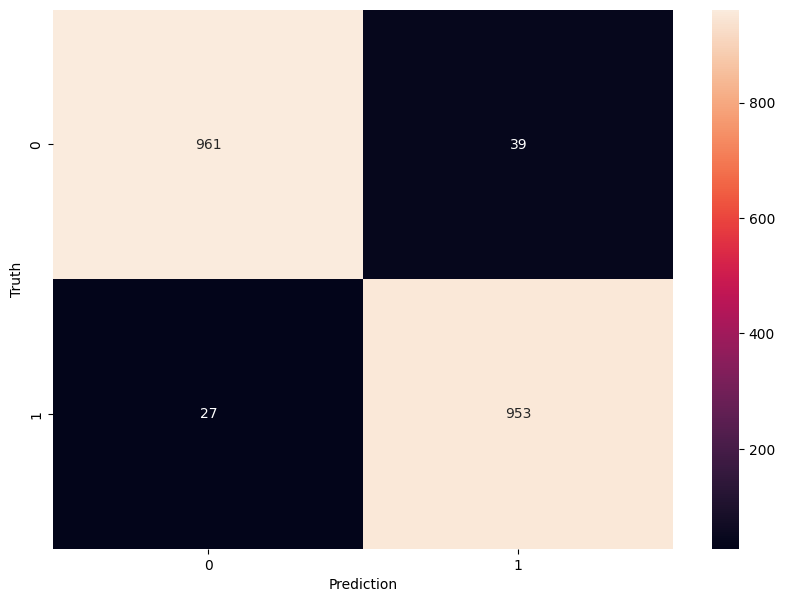

In [83]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show()